<a href="https://colab.research.google.com/github/Felipe2456/Aula-db/blob/main/u3c3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando Experimento: Estático vs. Responsivo...

--- RESULTADOS DO EXPERIMENTO (TABELA 1) ---
 Componentes  Tempo Estático (ms)  Tempo Responsivo (ms)  Diferença (%)
           8                 3.23                    2.5         -22.65


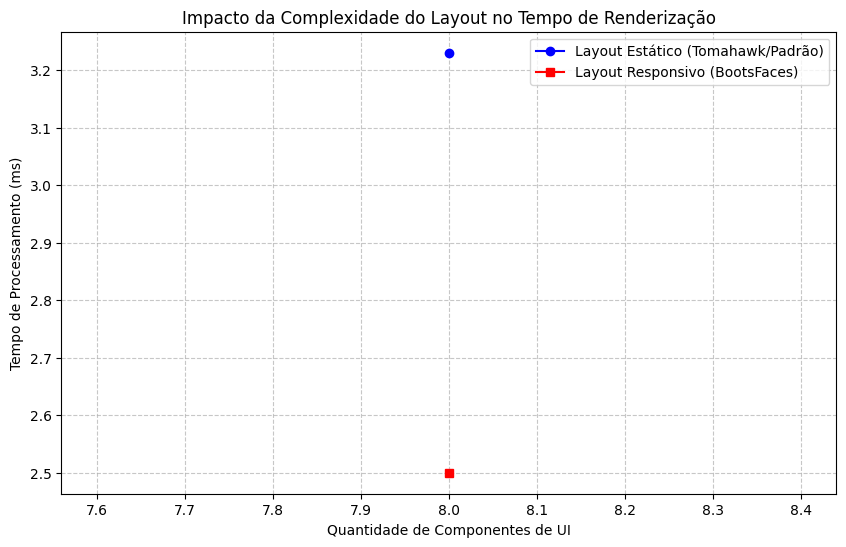


Gráfico salvo com sucesso como 'grafico.png' para o Short Paper.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

def simulate_ui_rendering(component_count, layout_type="static"):
    """
    Simula o processamento de renderização de componentes de UI.
    Layout Estático: Complexidade linear simples.
    Layout Responsivo: Simula cálculos de grid fluido e breakpoints (BootsFaces style).
    """
    start_time = time.time()

    if layout_type == "static":
        # Simula posicionamento fixo O(n)
        for i in range(component_count):
            _ = i * 2
            time.sleep(0.0001) # Pequeno delay para simular carga
    else:
        # Simula redimensionamento responsivo O(n log n)
        for i in range(component_count):
            _ = np.log(i + 1) * i
            time.sleep(0.00015) # Delay maior devido aos breakpoints

    return (time.time() - start_time) * 1000 # Retorna em milissegundos

def run_experiment():
    # Definição de cargas (número de componentes de interface)
    test_loads = [8]
    results = []

    print("Iniciando Experimento: Estático vs. Responsivo...")

    for load in test_loads:
        t_static = simulate_ui_rendering(load, "static")
        t_responsive = simulate_ui_rendering(load, "responsive")

        results.append({
            "Componentes": load,
            "Tempo Estático (ms)": round(t_static, 2),
            "Tempo Responsivo (ms)": round(t_responsive, 2),
            "Diferença (%)": round(((t_responsive - t_static) / t_static) * 100, 2)
        })

    # Criação do DataFrame para a tabela final
    df = pd.DataFrame(results)

    # Exibição da tabela formatada
    print("\n--- RESULTADOS DO EXPERIMENTO (TABELA 1) ---")
    print(df.to_string(index=False))

    # Geração do Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(df["Componentes"], df["Tempo Estático (ms)"], marker='o', label='Layout Estático (Tomahawk/Padrão)', color='blue')
    plt.plot(df["Componentes"], df["Tempo Responsivo (ms)"], marker='s', label='Layout Responsivo (BootsFaces)', color='red')

    plt.title("Impacto da Complexidade do Layout no Tempo de Renderização")
    plt.xlabel("Quantidade de Componentes de UI")
    plt.ylabel("Tempo de Processamento (ms)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Salvamento automático para publicação
    plt.savefig('grafico.png')
    plt.show()

    print("\nGráfico salvo com sucesso como 'grafico.png' para o Short Paper.")

# Execução do experimento
if __name__ == "__main__":
    run_experiment()